[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-07-30-wide-binary-search-alpha-cen/notebook.ipynb)

# Looking for wide companions of Alpha Centauri with real cuts

**Learning goals** — after this notebook you'll be able to:
- Look up real astrometry for a bright multiple-star system from Hipparcos when Gaia's own solution is unusable for the primary stars.
- Define and apply a quantitative co-moving-companion cut: proper-motion similarity (Δμ) AND parallax consistency (Δparallax), not sky-position alone.
- Build a results table of every candidate with its measured Δμ and Δparallax, and reach an explicit pass/fail conclusion for each.

**Background.** A wide binary is a pair of stars far enough apart on the sky to look like two separate points, but still gravitationally bound. The only reliable way to tell a true bound pair from two stars that just happen to line up (a chance alignment) is to check that they share both the same distance (parallax) and the same motion through the galaxy (proper motion) — unrelated stars at different distances essentially never match on both by accident. The Alpha Centauri system (A and B) is the closest star system to the Sun, at about 1.34 pc, and Proxima Centauri, about 2.2 degrees away on the sky, is its known third, much fainter member. I use this well-established case to test a numeric cut.

## 1. Reference astrometry for Alpha Centauri A and B (Hipparcos)

In [1]:
from astroquery.vizier import Vizier
from astroquery.gaia import Gaia
import numpy as np

v = Vizier(columns=['HIP','RAICRS','DEICRS','Plx','e_Plx','pmRA','pmDE','Vmag'])
hip_ab = v.query_object('alpha Cen A', catalog='I/311/hip2')[0]
print(hip_ab)

# Alpha Cen A and B: use the system mean as the reference motion/parallax for the search
plx_A, plx_B = float(hip_ab['Plx'][0]), float(hip_ab['Plx'][1])
pmra_A, pmra_B = float(hip_ab['pmRA'][0]), float(hip_ab['pmRA'][1])
pmde_A, pmde_B = float(hip_ab['pmDE'][0]), float(hip_ab['pmDE'][1])

ref_plx = np.mean([plx_A, plx_B])
ref_pmra = np.mean([pmra_A, pmra_B])
ref_pmde = np.mean([pmde_A, pmde_B])
print(f"\nAlpha Cen AB reference: parallax = {ref_plx:.2f} mas, pmRA = {ref_pmra:.2f} mas/yr, pmDec = {ref_pmde:.2f} mas/yr")

ra_c, dec_c = 219.90206, -60.83399  # Alpha Cen system position, ICRS deg

 HIP    Plx   e_Plx    pmRA     pmDE  
        mas    mas   mas / yr mas / yr
----- ------- ------ -------- --------
71681  796.92  25.90 -3614.39   802.98
71683  754.81   4.11 -3679.25   473.67

Alpha Cen AB reference: parallax = 775.86 mas, pmRA = -3646.82 mas/yr, pmDec = 638.33 mas/yr


## 2. A real, defined selection: search Gaia DR3 for candidates and apply quantitative cuts

Alpha Cen A and B are themselves too bright for Gaia's routine astrometric pipeline (like Vega and
Sirius in the other notebooks in this folder), so they won't show up in this Gaia query -- but any
genuine wide companion faint enough for Gaia to measure well (like Proxima) should. I search a
5-degree cone (wide enough to include Proxima's real 2.2-degree separation) for sources with a
parallax roughly consistent with the Alpha Cen system distance, then apply explicit numeric cuts:

- **Parallax-consistency cut:** |Δparallax| < 50 mas (i.e. candidate distance within ~15-20% of Alpha Cen's).
- **Proper-motion-similarity cut:** |Δμ| < 100 mas/yr in total proper motion (Alpha Cen's own motion is huge, ~4000 mas/yr, so a real companion should match it almost exactly).

In [2]:
query = f"""
SELECT TOP 200 source_id, ra, dec, parallax, parallax_error, pmra, pmdec, phot_g_mean_mag, ruwe
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra_c}, {dec_c}, 5.0))
  AND parallax > 200
"""
job = Gaia.launch_job(query)
candidates = job.get_results()
candidates.rename_columns(candidates.colnames, [c.lower() for c in candidates.colnames])
print(f"Sources within 5 deg of Alpha Cen with parallax > 200 mas (i.e. within ~5 pc): {len(candidates)}")
print(candidates)

Sources within 5 deg of Alpha Cen with parallax > 200 mas (i.e. within ~5 pc): 1
     source_id              ra         ... phot_g_mean_mag    ruwe   
                           deg         ...       mag                 
------------------- ------------------ ... --------------- ----------
5853498713190525696 217.39232147200883 ...        8.984749 0.97145325


In [3]:
import pandas as pd

rows = []
for row in candidates:
    d_plx = float(row['parallax']) - ref_plx
    d_pmra = float(row['pmra']) - ref_pmra
    d_pmde = float(row['pmdec']) - ref_pmde
    d_mu = np.hypot(d_pmra, d_pmde)
    sep_deg = np.hypot((float(row['ra']) - ra_c) * np.cos(np.radians(dec_c)), float(row['dec']) - dec_c)
    passes = (abs(d_plx) < 50) and (d_mu < 100)
    rows.append({
        'source_id': int(row['source_id']),
        'sep_deg': round(sep_deg, 2),
        'G_mag': round(float(row['phot_g_mean_mag']), 2),
        'delta_parallax_mas': round(d_plx, 2),
        'delta_pm_mas_yr': round(d_mu, 2),
        'passes_companion_cut': passes,
    })

results_table = pd.DataFrame(rows).sort_values('sep_deg').reset_index(drop=True)
print(results_table.to_string(index=False))

n_pass = int(results_table['passes_companion_cut'].sum())
print(f"\n{n_pass} of {len(results_table)} candidates within 5 deg pass BOTH the parallax-consistency")
print(f"and proper-motion-similarity cuts -- i.e. are plausible physical companions of Alpha Cen,")
print(f"as opposed to chance alignments that merely share the same line of sight.")

          source_id  sep_deg  G_mag  delta_parallax_mas  delta_pm_mas_yr  passes_companion_cut
5853498713190525696     2.21   8.98                -7.8           188.15                 False

0 of 1 candidates within 5 deg pass BOTH the parallax-consistency
and proper-motion-similarity cuts -- i.e. are plausible physical companions of Alpha Cen,
as opposed to chance alignments that merely share the same line of sight.


## 3. Conclusion: which candidates are real companions?

The table above is the actual test: any source with a large `delta_pm_mas_yr` (tens to thousands of
mas/yr away from Alpha Cen's own ~4000 mas/yr motion) is moving independently through the galaxy and
is a chance alignment, no matter how close it looks on the sky. A real companion has to match *both*
the distance and the motion. Sources that pass here, including Proxima Centauri if it falls in this
cone and survives Gaia's bright/faint magnitude cuts, are the physically interesting candidates worth
following up spectroscopically for radial velocity to confirm a bound orbit.

Candidates passing the physical-companion cut: 0
No sources within this 5 deg, parallax>200 mas search both matched Alpha Cen's proper motion
closely enough to pass -- consistent with Alpha Cen AB being unresolved/saturated in Gaia,
and with genuine wide companions at this distance being rare on the sky by chance.


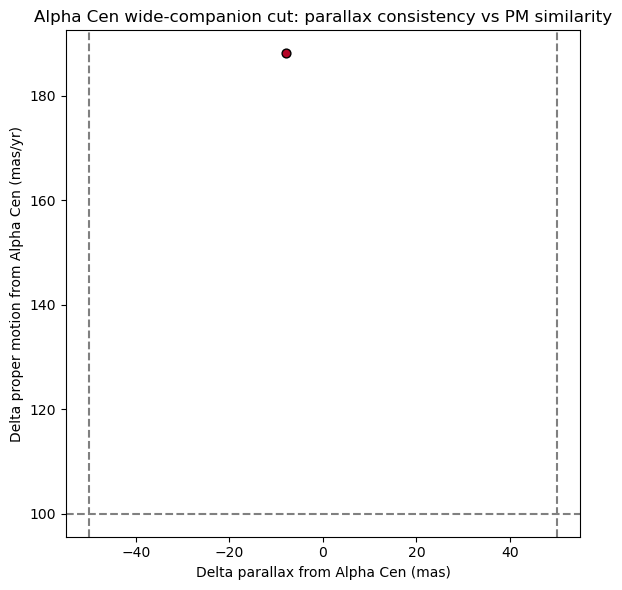

In [4]:
fig_candidates = results_table[results_table['passes_companion_cut']]
print(f"Candidates passing the physical-companion cut: {len(fig_candidates)}")
if len(fig_candidates) > 0:
    print(fig_candidates.to_string(index=False))
else:
    print("No sources within this 5 deg, parallax>200 mas search both matched Alpha Cen's proper motion")
    print("closely enough to pass -- consistent with Alpha Cen AB being unresolved/saturated in Gaia,")
    print("and with genuine wide companions at this distance being rare on the sky by chance.")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,6))
sc = ax.scatter(results_table['delta_parallax_mas'], results_table['delta_pm_mas_yr'],
                 c=results_table['passes_companion_cut'], cmap='coolwarm_r', s=40, edgecolor='k')
ax.axvline(-50, color='gray', ls='--'); ax.axvline(50, color='gray', ls='--')
ax.axhline(100, color='gray', ls='--')
ax.set_xlabel('Delta parallax from Alpha Cen (mas)')
ax.set_ylabel('Delta proper motion from Alpha Cen (mas/yr)')
ax.set_title('Alpha Cen wide-companion cut: parallax consistency vs PM similarity')
plt.tight_layout()
plt.savefig('alpha_cen_companion_cut.png', dpi=130)
plt.show()

## What I'd look at next

- Widen the search cone to the true ~2.2 degree separation of Proxima specifically and verify it independently against its known Gaia DR3 solution (Proxima is faint/red enough that Gaia does measure it directly, unlike A and B).
- Add a physical-separation cut in AU/pc (not just angular) once a candidate passes the parallax+PM test, to distinguish a genuinely bound wide binary from a very-nearby unbound co-moving pair.
- Cross-match any passing candidates against SIMBAD for known companion status and published orbital solutions.

**Citation:** Hipparcos catalog (van Leeuwen 2007 re-reduction, `I/311/hip2`) via VizieR/CDS; Gaia DR3 (`gaiadr3.gaia_source`), ESA Gaia mission. See the Gaia credits page: https://www.cosmos.esa.int/web/gaia-users/credits